In [1]:
!pip install ipympl scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install ipympl scipy matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Інструкція користувача

1. Запустіть комірку з кодом нижче.
2. **Параметри гармоніки:** Використовуйте повзунки `Амплітуда`, `Частота` та `Фаза` для зміни форми основної хвилі.
3. **Параметри шуму:** Повзунки `Шум (Середнє)` та `Шум (Дисперсія)` налаштовують перешкоди. Шум перераховується лише при зміні цих двох параметрів.
4. **Фільтрація:** Повзунок `Фільтр (Зріз)` керує частотою зрізу Low-pass Butterworth фільтра.
5. **Відображення:** Зліва є чекбокси для увімкнення/вимкнення відображення шуму та відфільтрованого сигналу.
6. **Скидання:** Кнопка `Reset` повертає всі параметри до початкового стану.

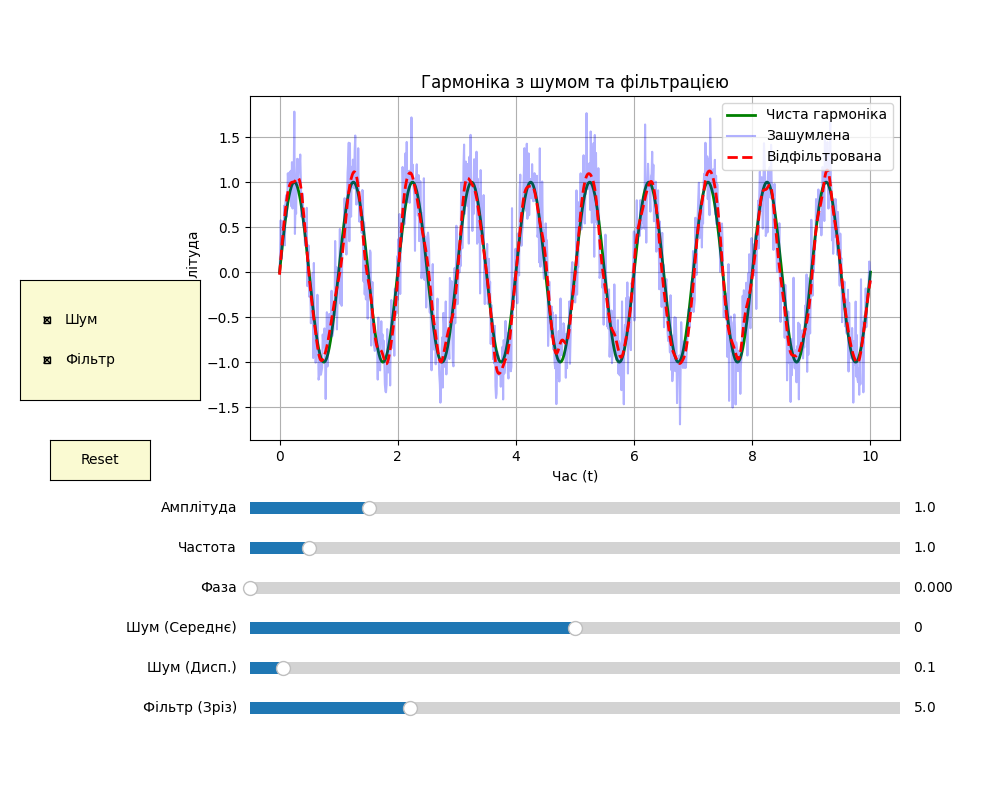

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

class HarmonicVisualizer:
    def __init__(self):
        self.t = np.linspace(0, 10, 1000)
        self.fs = 100 
        
        self.init_amp = 1.0
        self.init_freq = 1.0
        self.init_phase = 0.0
        self.init_nmean = 0.0
        self.init_ncov = 0.1
        self.init_cutoff = 5.0
        
        self.current_nmean = self.init_nmean
        self.current_ncov = self.init_ncov
        self.noise = np.random.normal(self.init_nmean, np.sqrt(self.init_ncov), len(self.t))
        
        self.setup_plot()
        
    def harmonic_with_noise(self, amplitude, frequency, phase, noise_mean, noise_covariance):
        if noise_mean != self.current_nmean or noise_covariance != self.current_ncov:
            self.current_nmean = noise_mean
            self.current_ncov = noise_covariance
            self.noise = np.random.normal(noise_mean, np.sqrt(max(0, noise_covariance)), len(self.t))
            
        clean_harmonic = amplitude * np.sin(2 * np.pi * frequency * self.t + phase)
        noisy_harmonic = clean_harmonic + self.noise
        
        return clean_harmonic, noisy_harmonic

    def apply_filter(self, data, cutoff):
        b, a = butter(3, cutoff, fs=self.fs, btype='low')
        return filtfilt(b, a, data)

    def setup_plot(self):
        self.fig, self.ax = plt.subplots(figsize=(10, 8))
        plt.subplots_adjust(left=0.25, bottom=0.45)
        
        clean_y, noisy_y = self.harmonic_with_noise(
            self.init_amp, self.init_freq, self.init_phase, 
            self.init_nmean, self.init_ncov
        )
        filtered_y = self.apply_filter(noisy_y, self.init_cutoff)
        
        self.line_clean, = self.ax.plot(self.t, clean_y, label='Чиста гармоніка', color='green', lw=2)
        self.line_noisy, = self.ax.plot(self.t, noisy_y, label='Зашумлена', color='blue', alpha=0.3)
        self.line_filtered, = self.ax.plot(self.t, filtered_y, label='Відфільтрована', color='red', linestyle='--', lw=2)
        
        self.ax.set_title("Гармоніка з шумом та фільтрацією")
        self.ax.set_xlabel("Час (t)")
        self.ax.set_ylabel("Амплітуда")
        self.ax.legend(loc='upper right')
        self.ax.grid(True)
        
        axcolor = 'lightgoldenrodyellow'
        
        ax_amp    = plt.axes([0.25, 0.35, 0.65, 0.03], facecolor=axcolor)
        ax_freq   = plt.axes([0.25, 0.30, 0.65, 0.03], facecolor=axcolor)
        ax_phase  = plt.axes([0.25, 0.25, 0.65, 0.03], facecolor=axcolor)
        ax_nmean  = plt.axes([0.25, 0.20, 0.65, 0.03], facecolor=axcolor)
        ax_ncov   = plt.axes([0.25, 0.15, 0.65, 0.03], facecolor=axcolor)
        ax_cutoff = plt.axes([0.25, 0.10, 0.65, 0.03], facecolor=axcolor)
        
        self.s_amp    = Slider(ax_amp, 'Амплітуда', 0.1, 5.0, valinit=self.init_amp)
        self.s_freq   = Slider(ax_freq, 'Частота', 0.1, 10.0, valinit=self.init_freq)
        self.s_phase  = Slider(ax_phase, 'Фаза', 0.0, 2*np.pi, valinit=self.init_phase)
        self.s_nmean  = Slider(ax_nmean, 'Шум (Середнє)', -2.0, 2.0, valinit=self.init_nmean)
        self.s_ncov   = Slider(ax_ncov, 'Шум (Дисп.)', 0.0, 2.0, valinit=self.init_ncov)
        self.s_cutoff = Slider(ax_cutoff, 'Фільтр (Зріз)', 0.1, 20.0, valinit=self.init_cutoff)
        
        ax_check = plt.axes([0.02, 0.5, 0.18, 0.15], facecolor=axcolor)
        self.checkboxes = CheckButtons(ax_check, ['Шум', 'Фільтр'], [True, True])
        
        ax_reset = plt.axes([0.05, 0.4, 0.1, 0.05])
        self.btn_reset = Button(ax_reset, 'Reset', color=axcolor, hovercolor='0.975')
        
        self.s_amp.on_changed(self.update)
        self.s_freq.on_changed(self.update)
        self.s_phase.on_changed(self.update)
        self.s_nmean.on_changed(self.update)
        self.s_ncov.on_changed(self.update)
        self.s_cutoff.on_changed(self.update)
        self.checkboxes.on_clicked(self.update_visibility)
        self.btn_reset.on_clicked(self.reset)
        
        plt.show()

    def update(self, val):
        clean_y, noisy_y = self.harmonic_with_noise(
            self.s_amp.val, self.s_freq.val, self.s_phase.val, 
            self.s_nmean.val, self.s_ncov.val
        )
        filtered_y = self.apply_filter(noisy_y, self.s_cutoff.val)
        
        self.line_clean.set_ydata(clean_y)
        self.line_noisy.set_ydata(noisy_y)
        self.line_filtered.set_ydata(filtered_y)
        self.fig.canvas.draw_idle()
        
    def update_visibility(self, label):
        status = self.checkboxes.get_status()
        self.line_noisy.set_visible(status[0])
        self.line_filtered.set_visible(status[1])
        self.fig.canvas.draw_idle()
        
    def reset(self, event):
        self.s_amp.reset()
        self.s_freq.reset()
        self.s_phase.reset()
        self.s_nmean.reset()
        self.s_ncov.reset()
        self.s_cutoff.reset()

app = HarmonicVisualizer()